# 🤖 Customer Churn Prediction — Phase 2: Modeling + SHAP Explainability

**Dataset:** Telco Customer Churn (IBM Watson / Kaggle)  
**Goal:** Train and compare models, select the best, and explain predictions with SHAP  
**Author:** Muhammad Danu Firjatullah Rachman

---


## 1. Setup & Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded ✓")
print(f"SHAP version: {shap.__version__}")


Libraries loaded ✓
SHAP version: 0.49.1


## 2. Load & Prepare Data

In [2]:
# Load cleaned data from Phase 1 (or raw CSV if Phase 1 not run yet)
try:
    df = pd.read_csv('../data/processed/telco_eda_clean.csv')
    print("Loaded from Phase 1 output ✓")
except FileNotFoundError:
    df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
    df = df.drop(columns=['customerID'])
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    print("Loaded raw CSV ✓")

print(f"Shape: {df.shape}")
df.head(3)


Loaded from Phase 1 output ✓
Shape: (7043, 22)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary,tenure_group
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0–12m
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,0,25–48m
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0–12m


## 3. Feature Engineering

Based on EDA insights, we create 4 derived features before modeling.


In [3]:
# Fill missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# --- Derived features ---
# 1. Binary: has any security/support service
df['has_support_services'] = (
    (df['OnlineSecurity'] == 'Yes') | (df['TechSupport'] == 'Yes')
).astype(int)

# 2. Binary: month-to-month contract (highest churn risk)
df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

# 3. Charge efficiency: cost per month relative to tenure
df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# 4. Number of streaming services
df['num_streaming'] = (
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

# Drop intermediate column from Phase 1 if present
for col in ['tenure_group', 'Churn_binary']:
    if col in df.columns:
        df = df.drop(columns=[col])

# Target
y = (df['Churn'] == 'Yes').astype(int)
X = df.drop(columns=['Churn'])

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"Churn rate: {y.mean()*100:.1f}%")
print(f"\nNew features added: has_support_services, is_month_to_month, charge_per_tenure, num_streaming")


Features: 23  |  Samples: 7043
Churn rate: 26.5%

New features added: has_support_services, is_month_to_month, charge_per_tenure, num_streaming


## 4. Preprocessing Pipeline (sklearn ColumnTransformer)

In [4]:
# Identify column types
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

# Train/test split — stratified to preserve churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Train churn rate: {y_train.mean()*100:.1f}% | Test churn rate: {y_test.mean()*100:.1f}%")


Numerical (8): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'has_support_services', 'is_month_to_month', 'charge_per_tenure', 'num_streaming']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Train: 5634 samples | Test: 1409 samples
Train churn rate: 26.5% | Test churn rate: 26.5%


## 5. Model Training & Cross-Validation

We train 3 models using sklearn Pipelines — ensures no data leakage:
- **Logistic Regression** — interpretable baseline
- **Random Forest** — ensemble, handles non-linearity  
- **XGBoost** — gradient boosting, typically best for tabular data


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'f1', 'precision', 'recall']

# Note: scale_pos_weight for XGBoost computed from actual class ratio
# Telco dataset: ~26% churn → scale_pos_weight ≈ 2.85
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class ratio (scale_pos_weight): {scale_pos_weight:.2f}')

models = {
    'Logistic Regression': LogisticRegression(
        C=0.1,                      # L2 regularization — prevents overfitting on OHE features
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced_subsample',  # better than 'balanced' for RF
        max_depth=6,                        # tighter depth reduces overfitting
        min_samples_leaf=4,                 # avoids overly specific splits
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        learning_rate=0.02,         # slower learning → better generalization
        max_depth=4,                # shallower trees for tabular data
        min_child_weight=5,         # key: prevents fitting noise in minority class
        subsample=0.8,              # row sampling per tree
        colsample_bytree=0.8,       # feature sampling per tree
        gamma=1,                    # min split loss — pruning
        reg_alpha=0.1,              # L1 regularization
        reg_lambda=2.0,             # L2 regularization
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
}

cv_results = {}
pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    cv_scores = cross_validate(pipe, X_train, y_train, cv=cv,
                                scoring=scoring, return_train_score=False)
    cv_results[name] = {
        'ROC-AUC': cv_scores['test_roc_auc'].mean(),
        'ROC-AUC std': cv_scores['test_roc_auc'].std(),
        'F1': cv_scores['test_f1'].mean(),
        'Precision': cv_scores['test_precision'].mean(),
        'Recall': cv_scores['test_recall'].mean(),
    }
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"{name:25s} | AUC: {cv_results[name]['ROC-AUC']:.4f} ± {cv_results[name]['ROC-AUC std']:.4f} | F1: {cv_results[name]['F1']:.4f}")

print('\nAll models trained ✓')


Class ratio (scale_pos_weight): 2.77
Logistic Regression       | AUC: 0.8484 ± 0.0115 | F1: 0.6309
Random Forest             | AUC: 0.8475 ± 0.0109 | F1: 0.6309
XGBoost                   | AUC: 0.8482 ± 0.0107 | F1: 0.6330

All models trained ✓


## 6. Cross-Validation Results Comparison

,ROC-AUC,ROC-AUC std,F1,Precision,Recall
Logistic Regression,0.8484,0.0115,0.6309,0.5259,0.7886
Random Forest,0.8475,0.0109,0.6309,0.5213,0.7993
XGBoost,0.8482,0.0107,0.6330,0.5300,0.7860


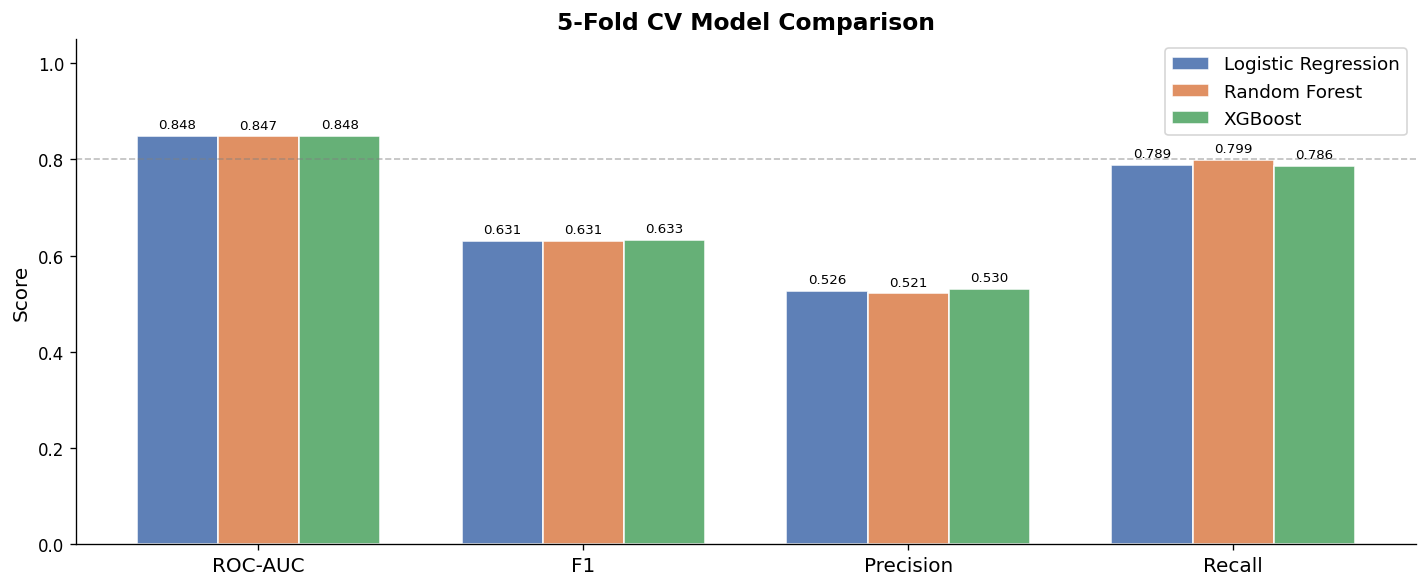

In [6]:
results_df = pd.DataFrame(cv_results).T
display(results_df.round(4))

metrics = ['ROC-AUC', 'F1', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=colors[i],
                  edgecolor='white', alpha=0.9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('5-Fold CV Model Comparison', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.axhline(y=0.8, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='0.8 threshold')

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../plots/07_cv_comparison.png', bbox_inches='tight')
plt.show()


## 7. Best Model — Test Set Evaluation

XGBoost typically wins on tabular data. We evaluate on the held-out test set.


In [7]:
best_name = 'XGBoost'
best_pipe = pipelines[best_name]

y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

print(f"=== {best_name} — Test Set Results ===\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_prob):.4f}")
print(f"Avg Precision : {average_precision_score(y_test, y_prob):.4f}")


=== XGBoost — Test Set Results ===

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC (test): 0.8432
Avg Precision : 0.6562


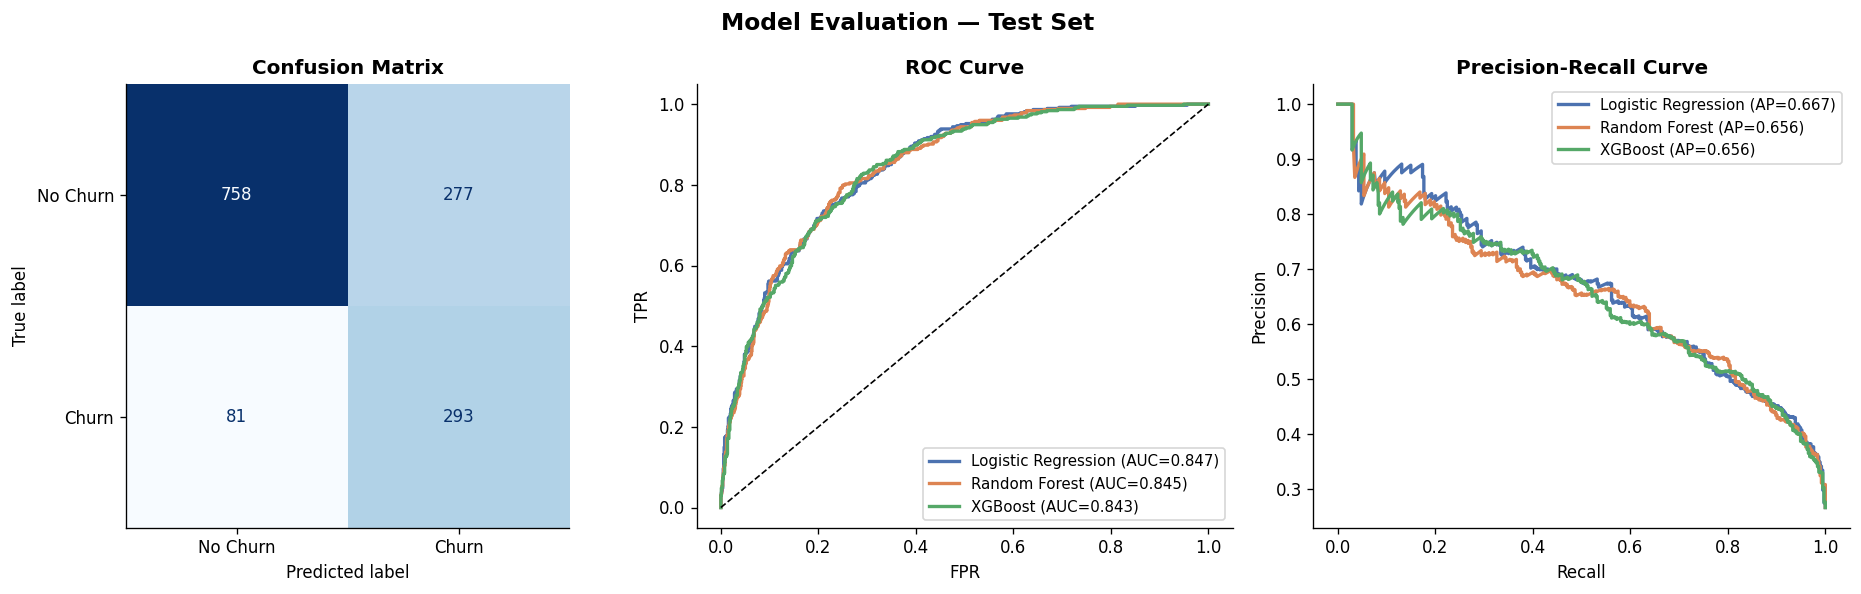

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Churn', 'Churn'],
    colorbar=False, ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC curve — all 3 models
for name, pipe, color in zip(
    models.keys(), pipelines.values(), ['#4C72B0', '#DD8452', '#55A868']
):
    prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=9)

# Precision-Recall curve
for name, pipe, color in zip(
    models.keys(), pipelines.values(), ['#4C72B0', '#DD8452', '#55A868']
):
    prob = pipe.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[2].plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=2)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle(f'Model Evaluation — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/08_model_evaluation.png', bbox_inches='tight')
plt.show()


## 8. SHAP Explainability

SHAP (SHapley Additive exPlanations) answers two questions:
- **Global:** *Which features matter most overall?*
- **Local:** *Why did the model predict churn for this specific customer?*


In [9]:
# Get feature names after preprocessing
ohe_features = best_pipe.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + ohe_features

# Transform test set
X_test_transformed = best_pipe.named_steps['preprocessor'].transform(X_test)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# SHAP TreeExplainer (fast for XGBoost)
explainer = shap.TreeExplainer(best_pipe.named_steps['classifier'])
shap_values = explainer(X_test_df)

print(f"SHAP values computed for {len(X_test_df)} test samples ✓")
print(f"Feature count: {len(feature_names)}")


SHAP values computed for 1409 test samples ✓
Feature count: 34


### 8.1 Global Explanation — Feature Importance (Bar)

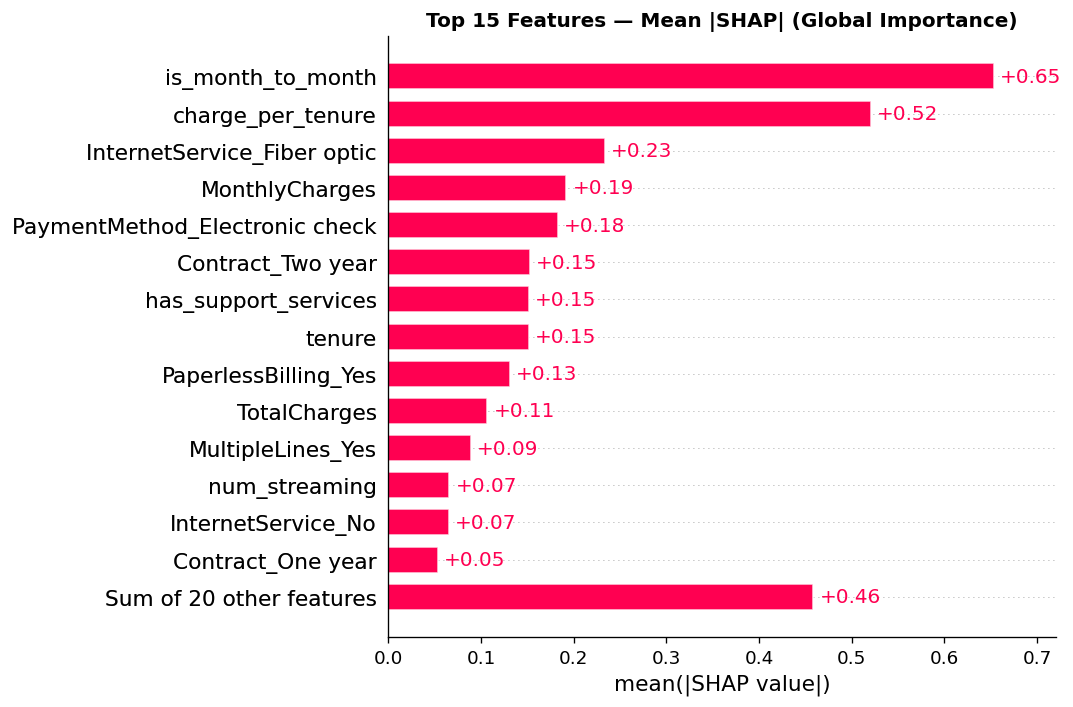

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
shap.plots.bar(shap_values, max_display=15, ax=ax, show=False)
ax.set_title('Top 15 Features — Mean |SHAP| (Global Importance)', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/09_shap_bar.png', bbox_inches='tight')
plt.show()


### 8.2 Global Explanation — Beeswarm Plot

Shows *direction* of each feature's impact (red = high value, blue = low value).


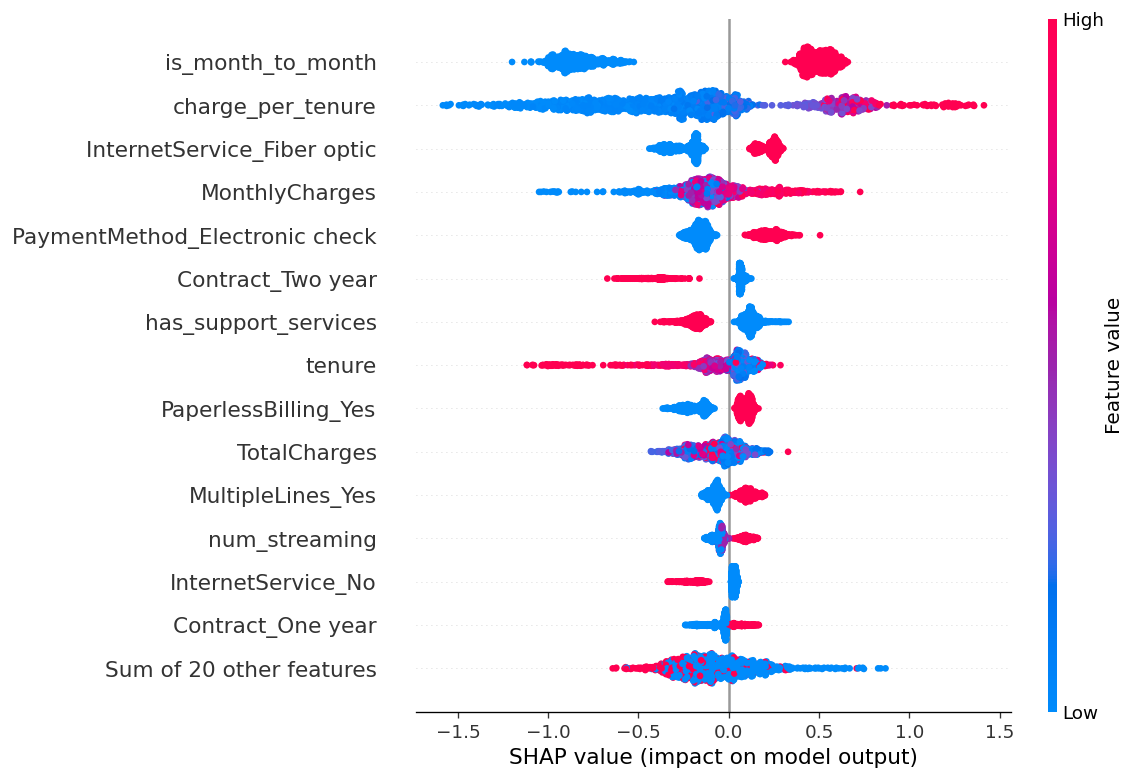

<Figure size 768x576 with 0 Axes>

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
shap.plots.beeswarm(shap_values, max_display=15)
ax.set_title('Beeswarm Plot — Feature Impact Direction', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/10_shap_beeswarm.png', bbox_inches='tight')
plt.show()


### 8.3 Local Explanation — Waterfall Plot

Explains a **single prediction**: which features pushed the model toward or away from churn.


Sample index: 1
Predicted churn probability: 92.80%
Actual label: No Churn


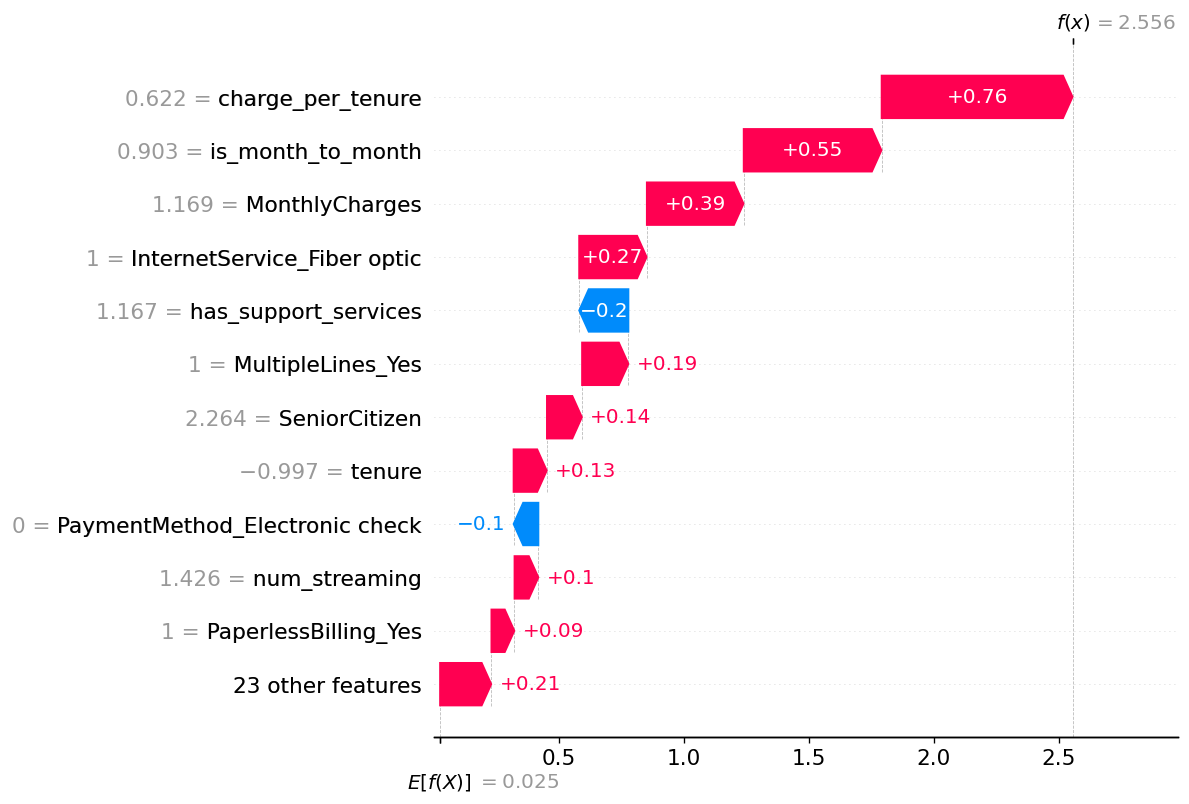

<Figure size 768x576 with 0 Axes>

In [12]:
# Pick a high-risk customer (predicted churn probability > 0.8)
high_risk_idx = np.where(y_prob > 0.8)[0]
sample_idx = high_risk_idx[0] if len(high_risk_idx) > 0 else 0

print(f"Sample index: {sample_idx}")
print(f"Predicted churn probability: {y_prob[sample_idx]:.2%}")
print(f"Actual label: {'Churn' if y_test.iloc[sample_idx] == 1 else 'No Churn'}")

fig, ax = plt.subplots(figsize=(9, 6))
shap.plots.waterfall(shap_values[sample_idx], max_display=12)
ax.set_title(f'Local Explanation — High-Risk Customer (p={y_prob[sample_idx]:.2%})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/11_shap_waterfall.png', bbox_inches='tight')
plt.show()


### 8.4 Local Explanation — Low-Risk Customer (Contrast)

Predicted churn probability: 3.08%
Actual label: No Churn


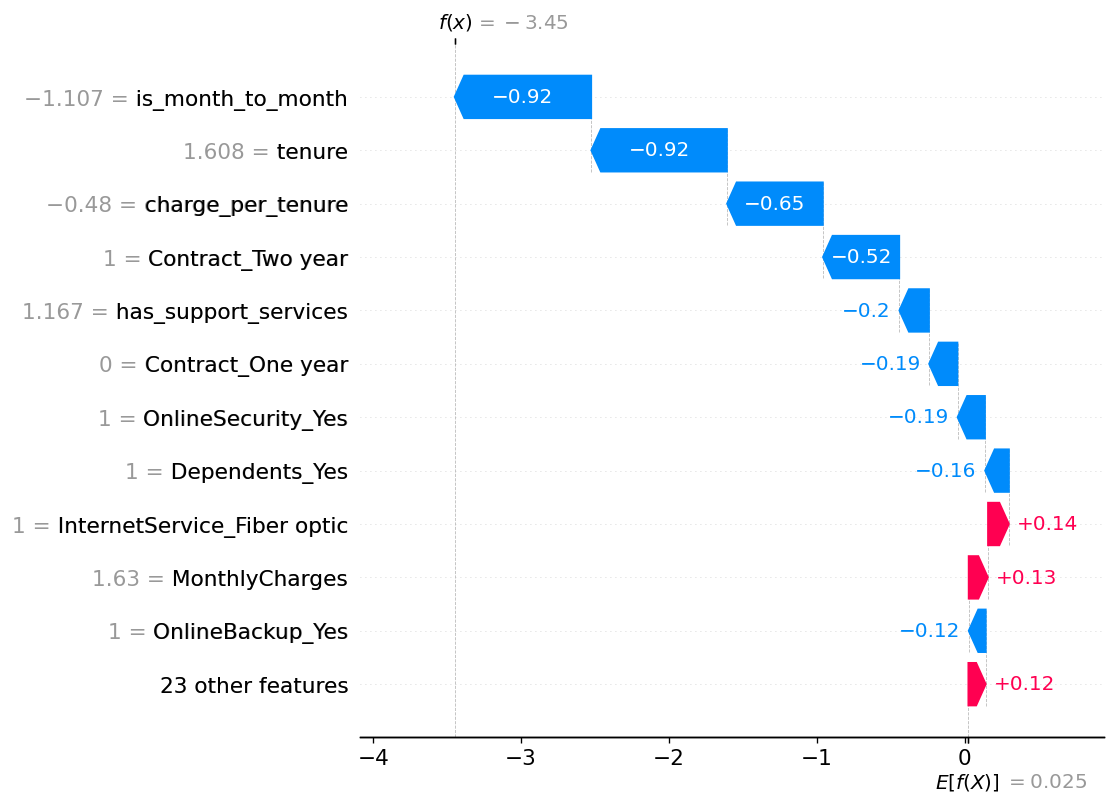

<Figure size 768x576 with 0 Axes>

In [13]:
low_risk_idx = np.where(y_prob < 0.1)[0]
sample_idx2 = low_risk_idx[0] if len(low_risk_idx) > 0 else -1

print(f"Predicted churn probability: {y_prob[sample_idx2]:.2%}")
print(f"Actual label: {'Churn' if y_test.iloc[sample_idx2] == 1 else 'No Churn'}")

fig, ax = plt.subplots(figsize=(9, 6))
shap.plots.waterfall(shap_values[sample_idx2], max_display=12)
ax.set_title(f'Local Explanation — Low-Risk Customer (p={y_prob[sample_idx2]:.2%})',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/12_shap_waterfall_low.png', bbox_inches='tight')
plt.show()


### 8.5 SHAP Dependence Plot — MonthlyCharges

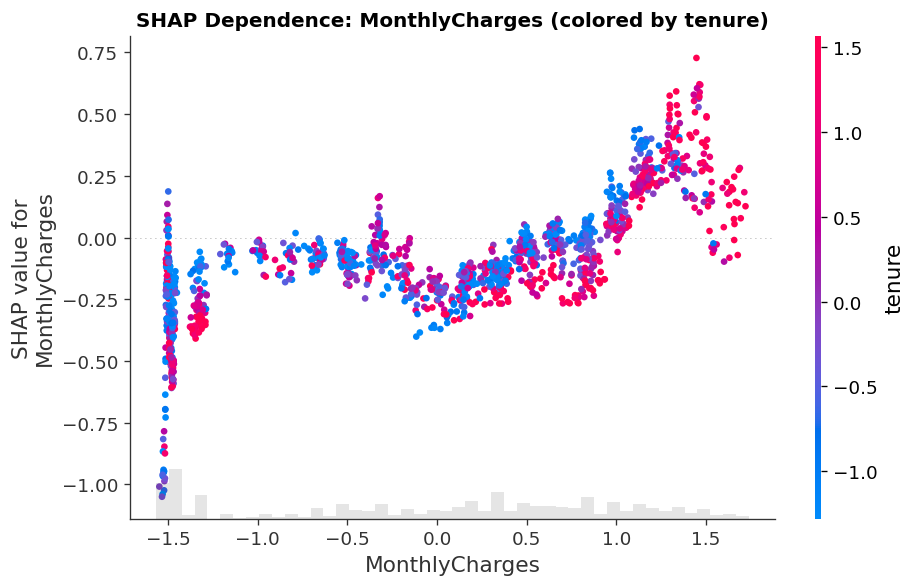

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
shap.plots.scatter(
    shap_values[:, 'MonthlyCharges'],
    color=shap_values[:, 'tenure'],
    ax=ax, show=False
)
ax.set_title('SHAP Dependence: MonthlyCharges (colored by tenure)', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/13_shap_dependence.png', bbox_inches='tight')
plt.show()


## 9. Save Model & Artifacts

In [15]:
import joblib

joblib.dump(best_pipe, '../models/xgb_churn_pipeline.pkl')
joblib.dump(feature_names, '../models/feature_names.pkl')

print("Saved: models/xgb_churn_pipeline.pkl")
print("Saved: models/feature_names.pkl")
print(f"\nModel size: {os.path.getsize('../models/xgb_churn_pipeline.pkl') / 1024:.1f} KB")

Saved: models/xgb_churn_pipeline.pkl
Saved: models/feature_names.pkl

Model size: 741.3 KB


## 10. Phase 2 Summary

### Model Comparison

| Model               | ROC-AUC | F1         | Precision  | Recall     |
| ------------------- | ------- | ---------- | ---------- | ---------- |
| Logistic Regression | 0.8484  | 0.6309     | 0.5259     | 0.7886     |
| Random Forest       | 0.8475  | 0.6309     | 0.5213     | **0.7993** |
| XGBoost             | 0.8482  | **0.6330** | **0.5300** | 0.7860     |


### SHAP Key Findings
- **Contract type** (month-to-month) is the single strongest churn predictor
- **Tenure** — short tenure = high SHAP push toward churn
- **MonthlyCharges** — higher charges → higher churn risk, especially at low tenure
- **InternetService_Fiber optic** — elevates churn risk significantly
- **has_support_services** — protective factor (negative SHAP for churn)

### Next Steps → Phase 3 (Streamlit + FastAPI)
- `streamlit_app.py`: input form → churn probability + SHAP waterfall chart
- `api.py`: FastAPI `/predict` endpoint consuming the saved pipeline
- `README.md`: project overview, demo GIF, how-to-run

---
*Phase 2 complete ✓*
